# v2.1 results layer — atlas, export, and `summary_figure`

This notebook is the canonical end-to-end demo of the ConnInfPy v2.1 results-layer surface. Five steps:

1. Load a synthetic two-group dataset (Schaefer-100 scale).
2. Run `analyze(...)` with the high-level wrapper.
3. Build an `AtlasInfo` so significant edges carry ROI names and Yeo-7 networks.
4. Call `result.significant_edges(atlas, sort='network_pair', top_k=20)` and `result.to_csv(...)` for a paper-ready edge table.
5. Render `summary_figure(result, atlas=...)` and save it to PDF.

Target runtime: ≲ 60 s on default hardware. We run on synthetic data so the notebook executes anywhere; the same pattern applies verbatim to ABIDE (`AtlasInfo.schaefer_100_yeo7()`), to Open-Close (`AtlasInfo.schaefer_200_yeo7()` with a 182-ROI subset), or to any custom atlas via `AtlasInfo.from_csv(...)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from conninfpy import AtlasInfo, analyze
from conninfpy.plot import summary_figure
from conninfpy.topologies import TopologyDatasetGenerator, get_scenario

## 1. Synthetic two-group dataset (n=30 + 30, 100 ROIs)

We plant a within-module-dense effect at modest effect size (`0.3`) so something real survives at α = 0.05.

In [2]:
gen = TopologyDatasetGenerator(n_nodes=100, n_modules=7, seed=42)
scenario = get_scenario("within_module_dense")
ds = gen.generate(scenario, effect_size=0.3, n_samples=30, time_points=120)

print("group1:", ds.group1.shape)
print("group2:", ds.group2.shape)
print("effect_mask sum (planted edges):", int(ds.effect_mask.sum() // 2))
print("net_labels unique:", np.unique(ds.net_labels).tolist())

group1: (30, 100, 100)
group2: (30, 100, 100)
effect_mask sum (planted edges): 52
net_labels unique: [0, 1, 2, 3, 4, 5, 6]


## 2. Run `analyze(...)`

Two-sample design, no harmonization (no `sites=` argument), TFNBS enhancement with the Hao 2024 FDR-calibrated regime (`e=0.4`, `h=3.0`, `n=10`). 200 permutations + GPD acceleration give equivalent FWER answers to ~5000 empirical permutations for ≈ 25× wall-clock savings (Winkler 2016).

In [3]:
out = analyze(
    group1=ds.group1,
    group2=ds.group2,
    test_type="two-sample",
    method="tfnbs",
    e=0.4, h=3.0, n=10,
    n_permutations=200,
    acceleration="gpd",
    rng=42,
)
print(out)

AnalyzeResult(inference=InferenceResult(method='tfnbs', n_perms=200, accel=gpd, sig@α=0.05: pos=103, neg=0, wall_time=1.80s))


## 3. Build an `AtlasInfo`

ConnInfPy ships `AtlasInfo.schaefer_{100,200,400}_yeo7()` and `AtlasInfo.bna_246()` out of the box. Here the synthetic dataset doesn't correspond to a real parcellation, so we build a custom `AtlasInfo` from the topology's network labels.

In [4]:
network_names = [f"Module {k}" for k in range(int(ds.net_labels.max() + 1))]
atlas = AtlasInfo(
    labels=[f"node_{i:03d}" for i in range(ds.group1.shape[1])],
    networks=[network_names[k] for k in ds.net_labels],
    source="synthetic — within_module_dense, 100 nodes, 7 modules",
)
print(f"AtlasInfo: {len(atlas)} ROIs across {len(set(atlas.networks))} networks")

AtlasInfo: 100 ROIs across 7 networks


## 4. Edge table — `significant_edges` and `to_csv`

Grouped by canonical network pair so the within-module signal lands first; truncated to the top 20 rows for the printout.

In [5]:
df = out.significant_edges(atlas, sort="network_pair", top_k=20, alpha=0.05)
display(df)

,edge_id,roi_i,roi_i_name,roi_i_network,roi_j,roi_j_name,roi_j_network,network_pair,t_signed,p_positive,p_negative,p_min,tail
0,0,0,node_000,Module 0,1,node_001,Module 0,Module 0—Module 0,4.829254,0.005,1.0,0.005,positive
1,1,0,node_000,Module 0,2,node_002,Module 0,Module 0—Module 0,7.486959,0.005,1.0,0.005,positive
2,2,0,node_000,Module 0,3,node_003,Module 0,Module 0—Module 0,4.387275,0.005,1.0,0.005,positive
3,3,0,node_000,Module 0,4,node_004,Module 0,Module 0—Module 0,6.264416,0.005,1.0,0.005,positive
4,4,0,node_000,Module 0,5,node_005,Module 0,Module 0—Module 0,4.800562,0.005,1.0,0.005,positive
5,5,0,node_000,Module 0,6,node_006,Module 0,Module 0—Module 0,5.688659,0.005,1.0,0.005,positive
6,6,0,node_000,Module 0,7,node_007,Module 0,Module 0—Module 0,7.983133,0.005,1.0,0.005,positive
7,7,0,node_000,Module 0,8,node_008,Module 0,Module 0—Module 0,8.761255,0.005,1.0,0.005,positive
8,8,0,node_000,Module 0,9,node_009,Module 0,Module 0—Module 0,5.892200,0.005,1.0,0.005,positive
9,9,0,node_000,Module 0,10,node_010,Module 0,Module 0—Module 0,4.430613,0.005,1.0,0.005,positive


In [6]:
out.to_csv("synthetic_significant_edges.csv", atlas=atlas, alpha=0.05)
print("wrote: synthetic_significant_edges.csv")

wrote: synthetic_significant_edges.csv


## 5. Publication-grade `summary_figure`

`conninfpy.plot.summary_figure` lays out a 2 × 2 panel: signed effect matrix (network-ordered when an atlas is supplied), block-level network-pair summary, positive-tail p-map, and a top-K significant-edge table. Returns a `matplotlib.figure.Figure` that you can save in any format `matplotlib` supports.

wrote: synthetic_summary.pdf


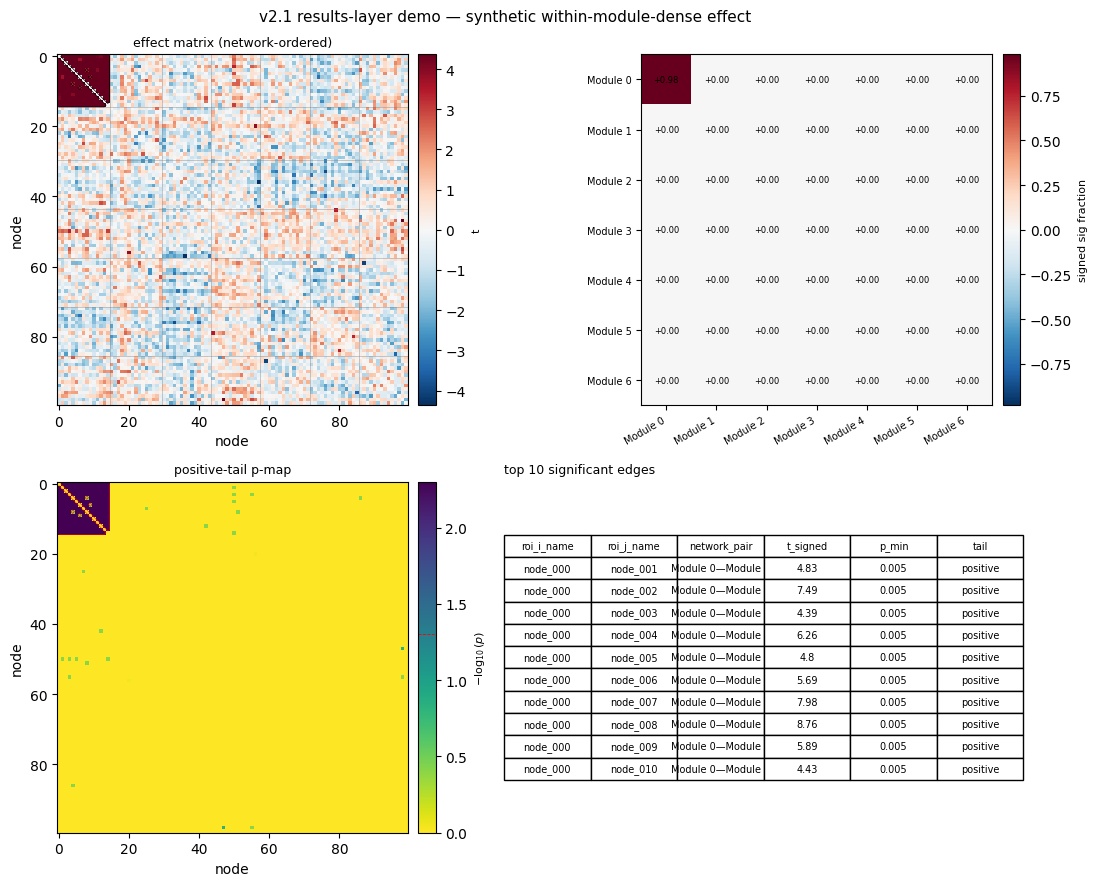

In [7]:
fig = summary_figure(
    out.inference,
    atlas=atlas,
    alpha=0.05,
    top_k=10,
    title="v2.1 results-layer demo — synthetic within-module-dense effect",
)
fig.savefig("synthetic_summary.pdf", bbox_inches="tight")
print("wrote: synthetic_summary.pdf")
plt.show()

## Where to take this next

- Swap the synthetic dataset for ABIDE I (`examples/abide_validation/run_age_combat_v2.py` shows the same pattern with `sites=site, harmonize='auto'`).
- Swap for Open-Close (`examples/openclose_validation/run_openclose_paired_v2.py` shows the paired test-type path).
- Build a `Schaefer-200` atlas with a 182-ROI subset by reading the bundled CSV directly: `AtlasInfo.from_csv('conninfpy/data/schaefer200_yeo7.csv').`.
- Generate the F-stat omnibus path: `analyze(..., interest=design, contrast=C, stat_type='fstat')` returns an `OmnibusInferenceResult` and the same `significant_edges` / `summary_figure` surface still works.

**Statistical caveat.** Significance is an FWER-controlled claim about edge-wise null rejection; an `α = 0.05` edge does not by itself establish a mechanism. The `significant_edges` table is most useful as a starting point for network-level reporting (`sort='network_pair'`).